In [ ]:
!pip install python-docx

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 12.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for python-docx: filename=python_docx-0.8.11-py3-none-any.whl size=184491 sha256=b4e699254365927e60f2b30ef740c36749bd275038621e743706c0b7eec5cbbf
  Stored in directory: /root/.cache/pip/wheels/80/27/06/837436d4c3bd989b957a91679966f207bfd71d358d63a8194d
Successfully built python-docx


In [ ]:
!pip install wordcloud


In [ ]:
!pip install pyLDAvis



In [ ]:
!pip install matplotlib

In [ ]:
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

# Function to clean the text
def clean_text(text):
    # Tokenize the text
    tokens = word_tokenize(text)

    # Remove stopwords
    stop_words = set(stopwords.words('english'))
    filtered_tokens = [word for word in tokens if word.lower() not in stop_words]

    # Lemmatize words
    lemmatizer = WordNetLemmatizer()
    cleaned_text = [lemmatizer.lemmatize(word.lower()) for word in filtered_tokens]

    return cleaned_text

# Replace 'healthcare_docs' with your list of healthcare document paths
healthcare_docs = ["//content//Apollo.docx",
    "//content//Dr.Reddys.docx",
    "//content//Fortis.docx",
    "//content//Manipal.docx",
    "//content//Max.docx"]

healthcare_cleaned_docs = []

# Clean each healthcare document
for doc_path in healthcare_docs:
    # Use the python-docx library to read text from the docx files
    from docx import Document
    doc = Document(doc_path)
    text = " ".join(paragraph.text for paragraph in doc.paragraphs)

    cleaned_text = clean_text(text)
    healthcare_cleaned_docs.append(cleaned_text)

# Access and print the cleaned text of each article separately
print("Cleaned Apollo Article:")
print(healthcare_cleaned_docs[0])
print()

print("Cleaned Dr. Reddys Article:")
print(healthcare_cleaned_docs[1])
print()

print("Cleaned Fortis Article:")
print(healthcare_cleaned_docs[2])
print()

print("Cleaned Manipal Article:")
print(healthcare_cleaned_docs[3])
print()

print("Cleaned Max Article:")
print(healthcare_cleaned_docs[4])
print()


AttributeError: ignored

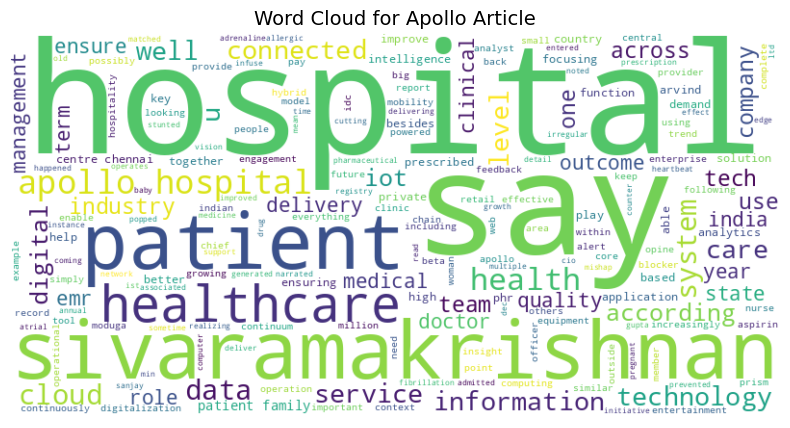

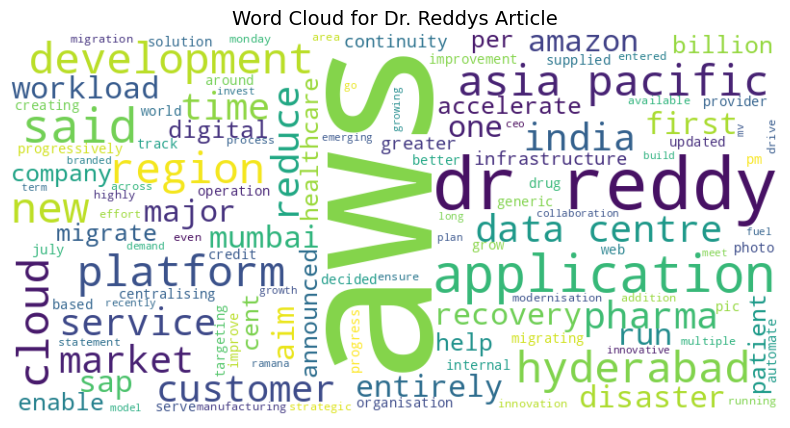

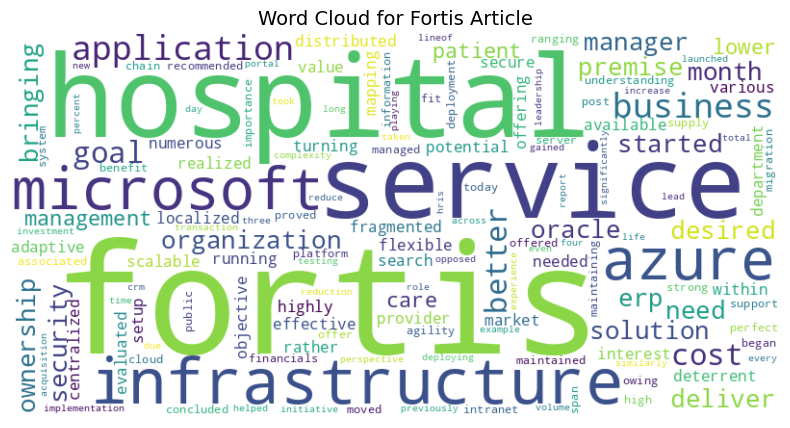

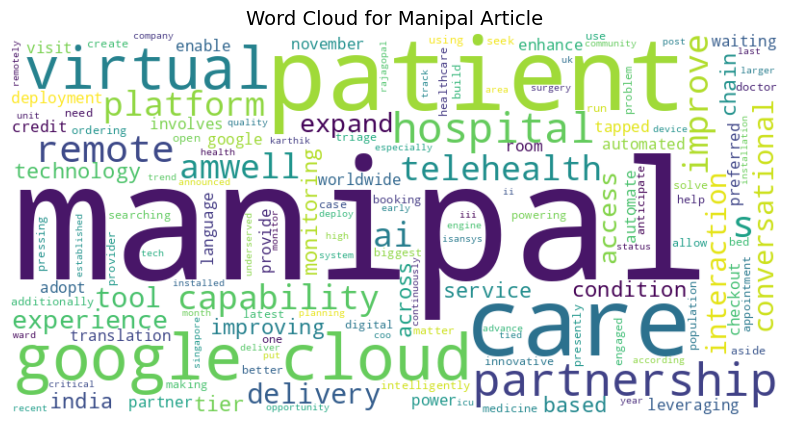

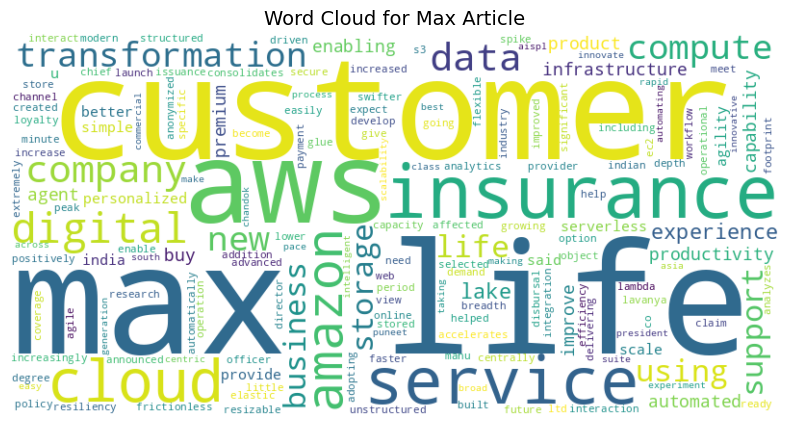

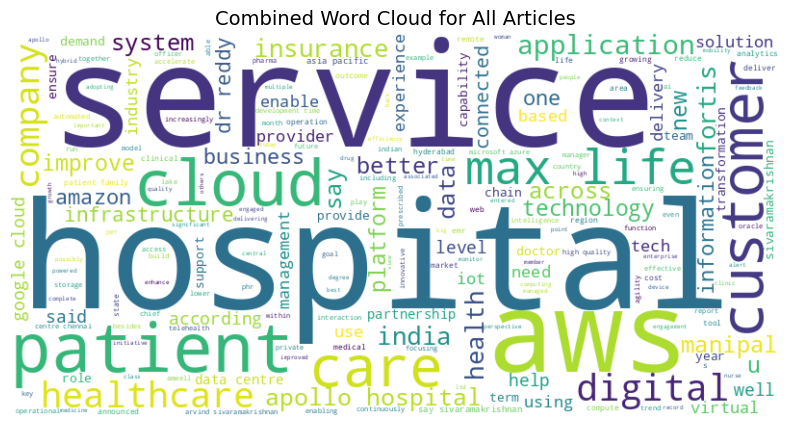

In [ ]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# Function to generate word cloud for given text
def generate_word_cloud(text, title):
    wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='viridis').generate(' '.join(text))
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(title, fontsize=14)
    plt.show()

# Generate word clouds for each healthcare article separately
article_titles = ['Apollo', 'Dr. Reddys', 'Fortis', 'Manipal', 'Max']
for i, article_text in enumerate(healthcare_cleaned_docs):
    title = "Word Cloud for " + article_titles[i] + " Article"
    generate_word_cloud(article_text, title)

# Combine all articles and generate a single word cloud
combined_text = [word for article in healthcare_cleaned_docs for word in article]
generate_word_cloud(combined_text, "Combined Word Cloud for All Articles")


In [ ]:
import gensim
from gensim import corpora
from gensim.models import LdaModel
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import re

# Function to clean and preprocess the text
def clean_text(text):
    # Remove special characters and digits
    text = re.sub(r'\W+', ' ', text)
    # Convert to lowercase
    text = text.lower()
    # Tokenize the text
    words = word_tokenize(text)
    # Remove stopwords
    stop_words = set(stopwords.words('english'))
    words = [word for word in words if word not in stop_words]
    return words

# Preprocess the healthcare documents
healthcare_cleaned_docs = [clean_text(doc) for doc in healthcare_docs]

# Create a dictionary and corpus for the healthcare domain
dictionary = corpora.Dictionary(healthcare_cleaned_docs)
corpus = [dictionary.doc2bow(doc) for doc in healthcare_cleaned_docs]

# LDA topic modeling for healthcare articles together
num_topics = 5  # Set the number of topics for LDA
lda_model_together = LdaModel(corpus, num_topics=num_topics, id2word=dictionary, passes=20)

# LDA topic modeling for healthcare articles separately
lda_models_separately = {}  # Dictionary to store LDA models for each article
for i, doc_path in enumerate(healthcare_docs):
    lda_model = LdaModel([corpus[i]], num_topics=num_topics, id2word=dictionary, passes=20)
    lda_models_separately[doc_path] = lda_model

# Function to print and visualize the topics
def print_topics(lda_model):
    topics = lda_model.print_topics(num_topics=num_topics)
    for topic in topics:
        print(topic)

# Print and visualize the topics for healthcare articles together
print("Topics for healthcare articles together:")
print_topics(lda_model_together)

# Print and visualize the topics for healthcare articles separately
for doc_path, lda_model in lda_models_separately.items():
    print(f"Topics for {doc_path}:")
    print_topics(lda_model)
    print("\n")


Topics for healthcare articles together:
(0, '0.276*"docx" + 0.276*"content" + 0.103*"reddys" + 0.103*"dr" + 0.103*"manipal" + 0.103*"apollo" + 0.017*"max" + 0.017*"fortis"')
(1, '0.125*"content" + 0.125*"docx" + 0.125*"manipal" + 0.125*"apollo" + 0.125*"dr" + 0.125*"reddys" + 0.125*"max" + 0.125*"fortis"')
(2, '0.290*"content" + 0.290*"docx" + 0.158*"fortis" + 0.158*"max" + 0.026*"manipal" + 0.026*"apollo" + 0.026*"dr" + 0.026*"reddys"')
(3, '0.125*"docx" + 0.125*"content" + 0.125*"manipal" + 0.125*"apollo" + 0.125*"dr" + 0.125*"reddys" + 0.125*"max" + 0.125*"fortis"')
(4, '0.125*"docx" + 0.125*"content" + 0.125*"apollo" + 0.125*"manipal" + 0.125*"dr" + 0.125*"reddys" + 0.125*"max" + 0.125*"fortis"')
Topics for //content//Apollo.docx:
(0, '0.125*"docx" + 0.125*"apollo" + 0.125*"content" + 0.125*"dr" + 0.125*"reddys" + 0.125*"fortis" + 0.125*"manipal" + 0.125*"max"')
(1, '0.125*"apollo" + 0.125*"docx" + 0.125*"content" + 0.125*"dr" + 0.125*"reddys" + 0.125*"fortis" + 0.125*"manipal" + 

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)
/usr/local/lib/python3.10/dist-packages/gensim/models/ldamodel.py:847: RuntimeWarning: divide by zero encountered in double_scalars
  perwordbound = self.bound(chunk, subsample_ratio=subsample_ratio) / (subsample_ratio * corpus_words)
/usr/local/lib/python3.10/dist-packages/gensim/models/ldamodel.py:847: RuntimeWarning: invalid value encountered in double_scalars
  perwordbound = self.bound(chunk, subsample_ratio=subsample_ratio) / (subsample_ratio * corpus_words)
/usr/local/lib/python3.10/dist-packages/gensim/models/ldamodel.py:847: RuntimeWarning: divide by zero encountered in double_scalars
  perwordbound = self.bound(chunk, subsample

Visualization for Apollo.docx:
Visualization for Dr.Reddys.docx:
Visualization for Fortis.docx:
Visualization for Manipal.docx:
Visualization for Max.docx:


In [ ]:
num_topics = 5
lda_model_together = LdaModel(corpus=corpus, id2word=dictionary, num_topics=num_topics, passes=10)

# Visualization for healthcare articles together
lda_display = gensimvis.prepare(lda_model_together, corpus, dictionary, sort_topics=False)
pyLDAvis.display(lda_display)

NameError: ignored